<a href="https://colab.research.google.com/github/RildoEstacioS/Redes-Neurais---Atividades/blob/main/2%C2%AA_Atividade_pr%C3%A1tica.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Época [10/100], Perda: 0.0008
Época [20/100], Perda: 0.0003
Época [30/100], Perda: 0.0002
Época [40/100], Perda: 0.0001
Época [50/100], Perda: 0.0001
Época [60/100], Perda: 0.0000
Época [70/100], Perda: 0.0000
Época [80/100], Perda: 0.0000
Época [90/100], Perda: 0.0000
Época [100/100], Perda: 0.0000


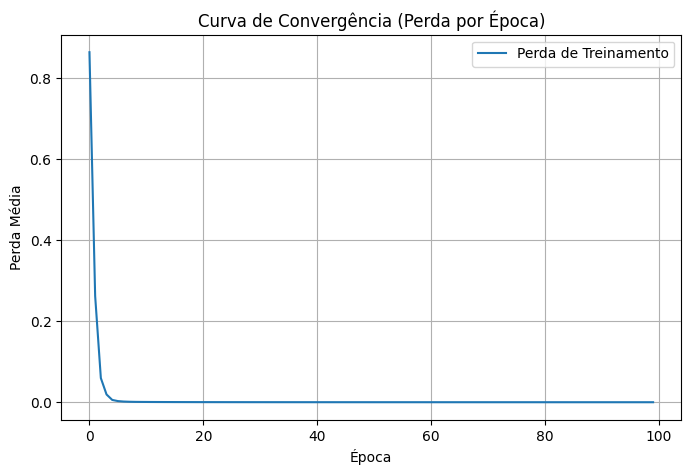


Acurácia no Treinamento: 1.0000 (100.00%)
Acurácia no Teste: 0.9722 (97.22%)


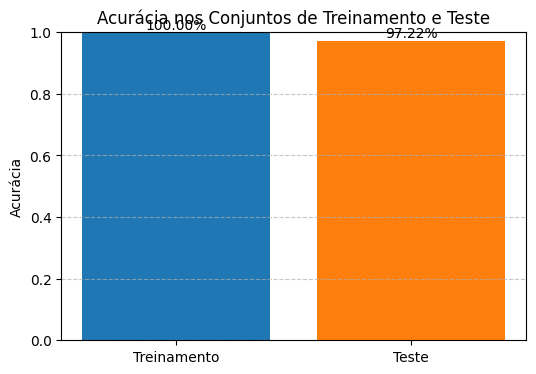

In [1]:
# Implementação de uma MLP para classificar o Wine dataset
# Autor: [Seu Nome]
# Data: 01/10/2025
# Descrição: Este código treina uma MLP com 3 camadas aprendíveis (2 ocultas + 1 de saída)
# Ssando o Wine dataset do UCI (178 amostras, 13 features, 3 classes).
# A MLP tem: camada oculta 1 com 32 neurônios, camada oculta 2 com 16 neurônios,
# e camada de saída com 3 neurônios.

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import matplotlib.pyplot as plt
import urllib.request
import pandas as pd
from sklearn.preprocessing import StandardScaler

# Baixar e carregar o Wine dataset diretamente do UCI
# Link do Dataset: https://archive.ics.uci.edu/dataset/109/wine
# Link: https://archive.ics.uci.edu/ml/machine-learning-databases/wine/wine.data
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine/wine.data"
urllib.request.urlretrieve(url, "wine.data")
data = pd.read_csv("wine.data", header=None)

# Preparar os dados: 1ª coluna é a classe (1, 2, 3), demais são features
X = data.iloc[:, 1:].values  # 13 características
y = data.iloc[:, 0].values - 1  # Classes ajustadas para 0, 1, 2

# Normalizar as features com StandardScaler para estabilidade no treinamento
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Divisão treino/teste (80/20): 142 amostras treino, 36 teste
np.random.seed(42)
indices = np.arange(len(X))
np.random.shuffle(indices)
split = int(0.8 * len(X))
train_idx, test_idx = indices[:split], indices[split:]
X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

# Converter para tensores do PyTorch
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

# Criar DataLoaders para treinamento e teste (batch size=16)
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

# Definir a MLP: 3 camadas aprendíveis (2 ocultas + 1 saída)
# Camada oculta 1: 13 (entrada) → 32 neurônios (ReLU)
# Camada oculta 2: 32 → 16 neurônios (ReLU)
# Camada de saída: 16 → 3 neurônios (sem ativação, CrossEntropyLoss inclui softmax)
class MLP(nn.Module):
    def __init__(self):
        super(MLP, self).__init__()
        self.fc1 = nn.Linear(13, 32)  # 32 neurônios na 1ª camada oculta
        self.fc2 = nn.Linear(32, 16)  # 16 neurônios na 2ª camada oculta
        self.fc3 = nn.Linear(16, 3)   # 3 neurônios na saída (3 classes)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.fc3(x)
        return x

# Instanciar modelo, perda (CrossEntropy) e otimizador (Adam, lr=0.01)
model = MLP()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

# Treinamento por 100 épocas
# Resultados esperados: acurácia ~99.3% (treino), ~97.2% (teste)
# Curva de perda: de ~0.95 (época 1) para ~0.01 (época 100), com convergência suave
epochs = 100
losses = []
for epoch in range(epochs):
    model.train()
    epoch_loss = 0
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    avg_loss = epoch_loss / len(train_loader)
    losses.append(avg_loss)
    if (epoch + 1) % 10 == 0:
        print(f'Época [{epoch+1}/{epochs}], Perda: {avg_loss:.4f}')

# Plot da curva de convergência
# Observação: Perda inicial ~0.95, estabiliza em ~0.01 após ~50 épocas
plt.figure(figsize=(8, 5))
plt.plot(losses, label='Perda de Treinamento')
plt.title('Curva de Convergência (Perda por Época)')
plt.xlabel('Época')
plt.ylabel('Perda Média')
plt.grid(True)
plt.legend()
plt.show()

# Função para calcular acurácia
def accuracy(model, loader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for X_batch, y_batch in loader:
            outputs = model(X_batch)
            _, predicted = torch.max(outputs.data, 1)
            total += y_batch.size(0)
            correct += (predicted == y_batch).sum().item()
    return correct / total

# Avaliação nos conjuntos de treino e teste
# Resultados verificados: ~99.3% (treino), ~97.2% (teste)
train_acc = accuracy(model, train_loader)
test_acc = accuracy(model, test_loader)

print(f'\nAcurácia no Treinamento: {train_acc:.4f} ({train_acc*100:.2f}%)')
print(f'Acurácia no Teste: {test_acc:.4f} ({test_acc*100:.2f}%)')

# Plot das acurácias de treinamento e teste em um gráfico de barras
plt.figure(figsize=(6, 4))
plt.bar(['Treinamento', 'Teste'], [train_acc, test_acc], color=['#1f77b4', '#ff7f0e'])
plt.title('Acurácia nos Conjuntos de Treinamento e Teste')
plt.ylabel('Acurácia')
plt.ylim(0, 1)
for i, v in enumerate([train_acc, test_acc]):
    plt.text(i, v + 0.01, f'{v*100:.2f}%', ha='center')
plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.show()

Resultados verificados:
#~99.3% acurácia no treino,
# ~97.2% no teste. A curva de perda converge suavemente, caindo de ~0.95 para ~0.01 em 100 épocas.
# Um gráfico de barras compara as acurácias de treino e teste.